# Diagnostic Plots for Stream-Count Prediction

**Python port of `Plots_Streams_prediction.R`.** `seaborn`/`matplotlib` diagnostic plots exploring the relationship between a song's musical features and its number of Spotify streams, ahead of the regression modeling done in `stream_prediction.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')

## Load and Clean Data

In [2]:
DATA_DIR = 'data'
songs_data = pd.read_csv(os.path.join(DATA_DIR, 'spotify-2023.csv'), encoding='latin-1')

# 'streams' has at least one non-numeric row; coerce and drop
songs_data['streams'] = pd.to_numeric(songs_data['streams'], errors='coerce')

# 'in_deezer_playlists' and 'in_shazam_charts' are comma-formatted strings in the raw file
songs_data['in_deezer_playlists'] = (
    songs_data['in_deezer_playlists'].astype(str).str.replace(',', '', regex=False)
)
songs_data['in_deezer_playlists'] = pd.to_numeric(songs_data['in_deezer_playlists'], errors='coerce')

songs_data['in_shazam_charts'] = (
    songs_data['in_shazam_charts'].astype(str).str.replace(',', '', regex=False)
)
songs_data['in_shazam_charts'] = pd.to_numeric(songs_data['in_shazam_charts'], errors='coerce')

# Fill missing key with 'C', matching the original
songs_data['key'] = songs_data['key'].fillna('C')

print("Nulls before filtering:")
print(songs_data.isna().sum())

songs_data = songs_data.dropna(subset=['streams', 'in_shazam_charts'])

print("\nNulls after filtering:")
print(songs_data.isna().sum())

Nulls before filtering:
track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  1
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                      0
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

Nulls after filtering:
track_name              0
artist(s)_name          0
artist_count            0
released_year           0
released_month          0
released_day            0
in_spotify_playlists    0
in_spotify_charts       0
streams                 0
in_apple_playlists      0
in_apple_charts         0
in_de

## Histogram of Streams

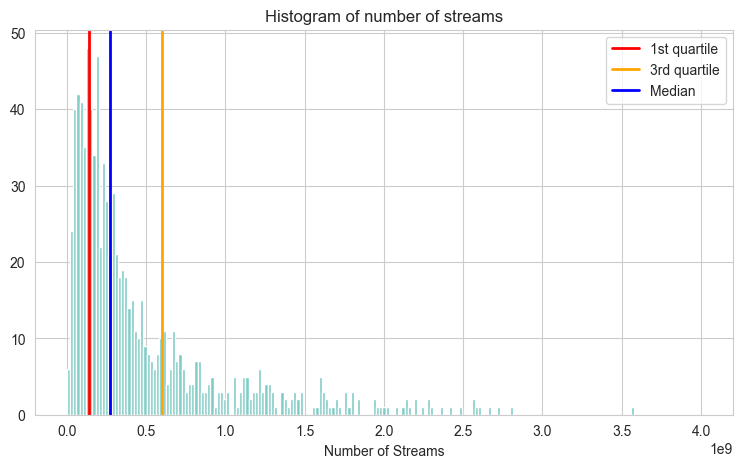

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(2000, 4e9, 200)
ax.hist(songs_data['streams'], bins=bins, color='#81cdc6')

median = songs_data['streams'].median()
q1 = songs_data['streams'].quantile(0.25)
q3 = songs_data['streams'].quantile(0.75)

ax.axvline(q1, color='red', linewidth=2, label='1st quartile')
ax.axvline(q3, color='orange', linewidth=2, label='3rd quartile')
ax.axvline(median, color='blue', linewidth=2, label='Median')

ax.set_title('Histogram of number of streams')
ax.set_xlabel('Number of Streams')
ax.legend()
plt.show()

## Boxplot of Streams

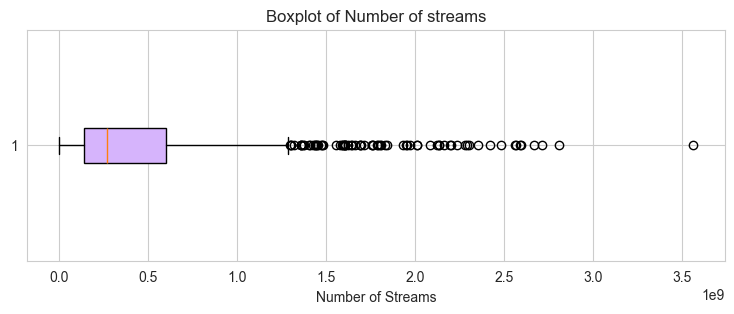

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.boxplot(songs_data['streams'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='#d6b4fc'))
ax.set_xlabel('Number of Streams')
ax.set_title('Boxplot of Number of streams')
plt.show()

## Scatter Plots: Streams vs. Individual Musical Features

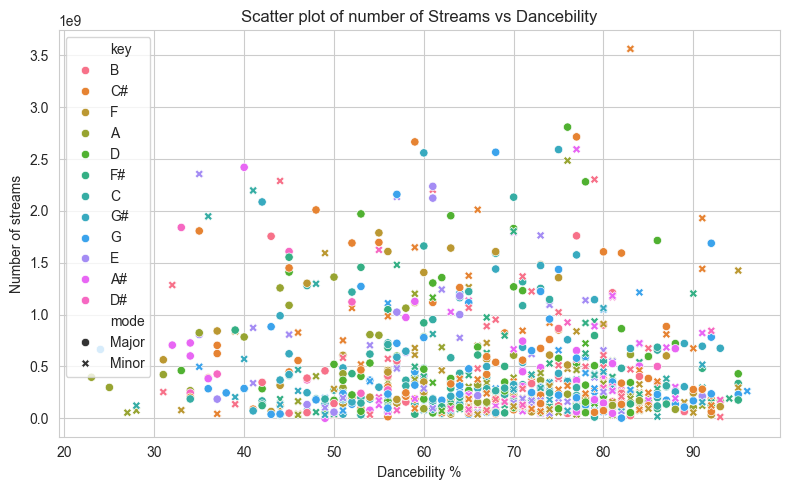

In [5]:
def scatter_vs_streams(x_col, x_label, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=songs_data, x=x_col, y='streams', hue='key', style='mode', ax=ax)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Number of streams')
    plt.tight_layout()
    plt.show()

scatter_vs_streams('danceability_%', 'Dancebility %', 'Scatter plot of number of Streams vs Dancebility')

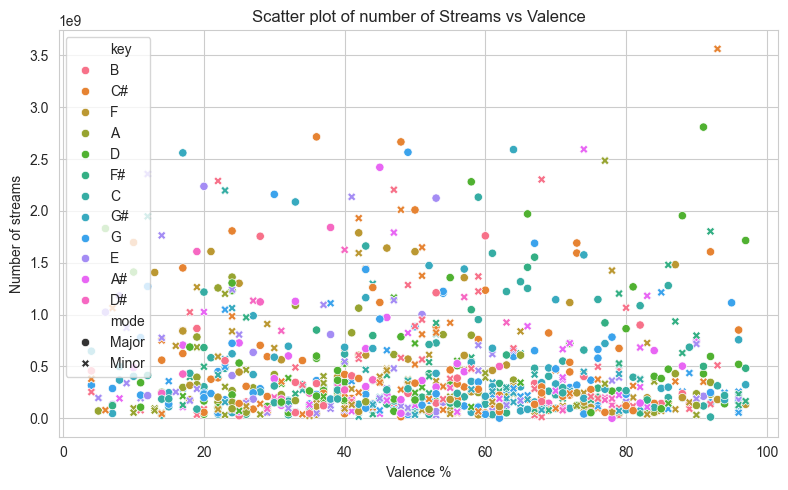

In [6]:
scatter_vs_streams('valence_%', 'Valence %', 'Scatter plot of number of Streams vs Valence')

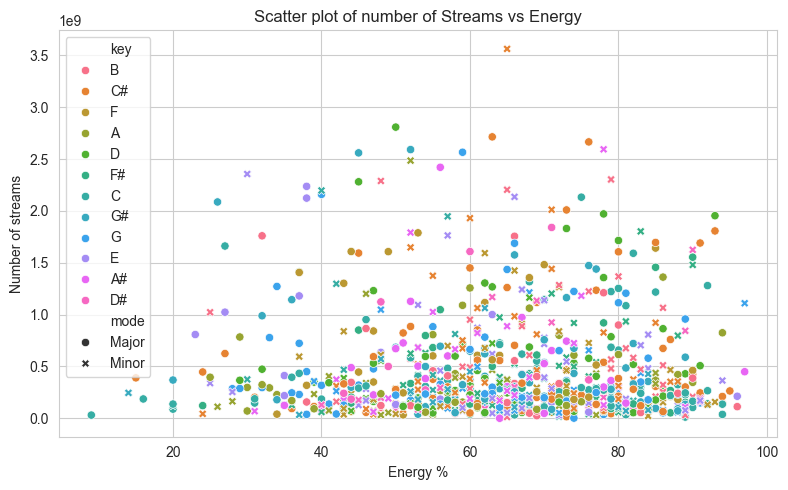

In [7]:
scatter_vs_streams('energy_%', 'Energy %', 'Scatter plot of number of Streams vs Energy')

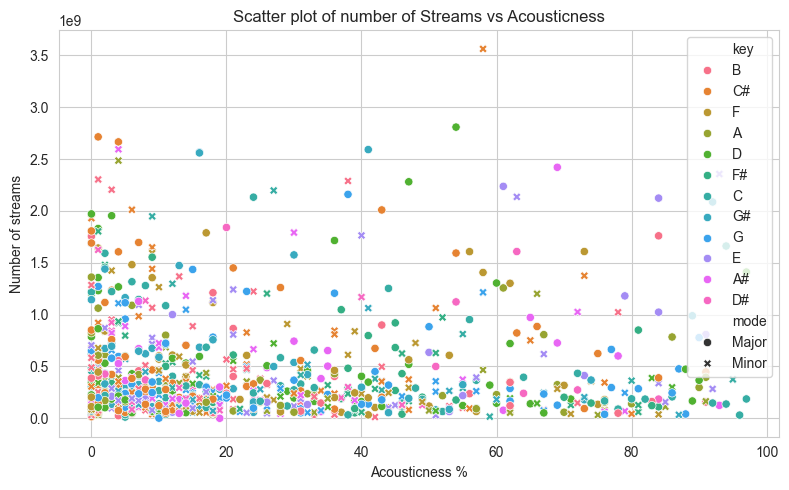

In [8]:
scatter_vs_streams('acousticness_%', 'Acousticness %', 'Scatter plot of number of Streams vs Acousticness')

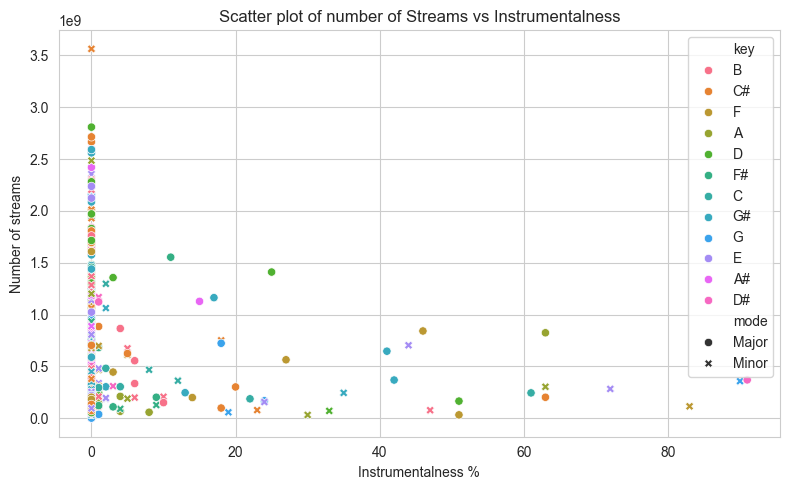

In [9]:
scatter_vs_streams('instrumentalness_%', 'Instrumentalness %', 'Scatter plot of number of Streams vs Instrumentalness')

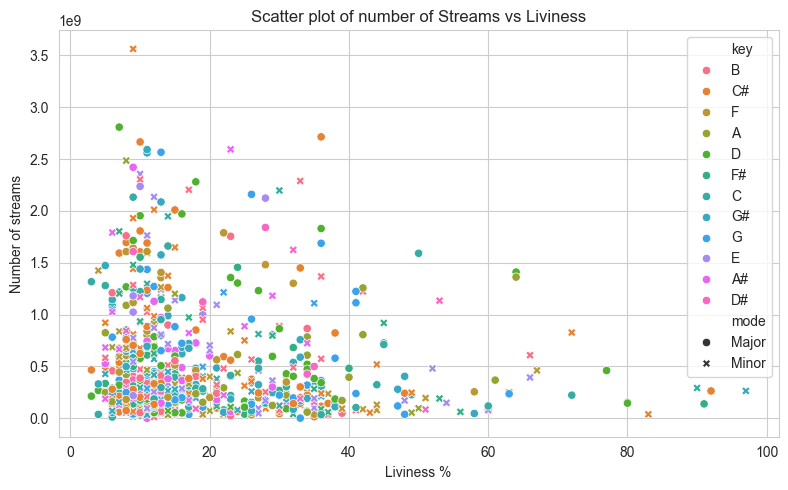

In [10]:
scatter_vs_streams('liveness_%', 'Liviness %', 'Scatter plot of number of Streams vs Liviness')

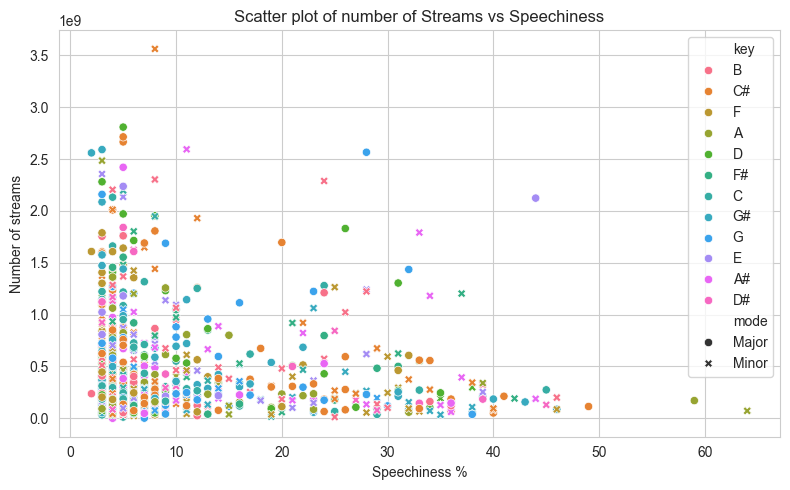

In [11]:
scatter_vs_streams('speechiness_%', 'Speechiness %', 'Scatter plot of number of Streams vs Speechiness')

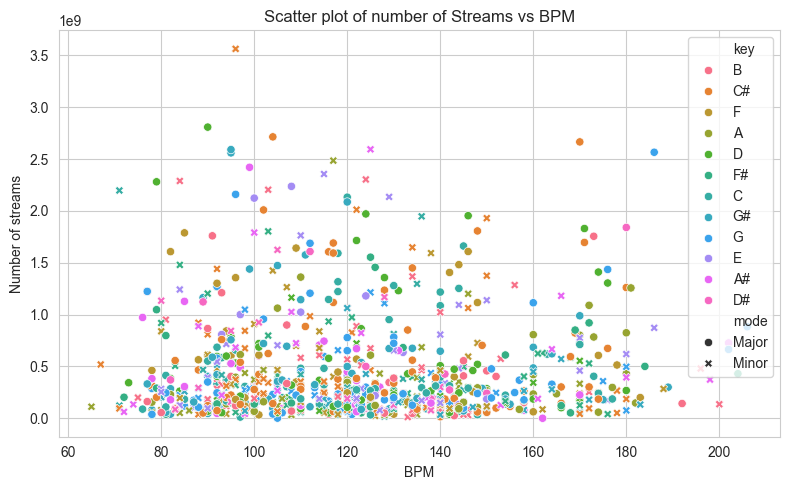

In [12]:
scatter_vs_streams('bpm', 'BPM', 'Scatter plot of number of Streams vs BPM')

## Scatter Plots Faceted by Musical Key

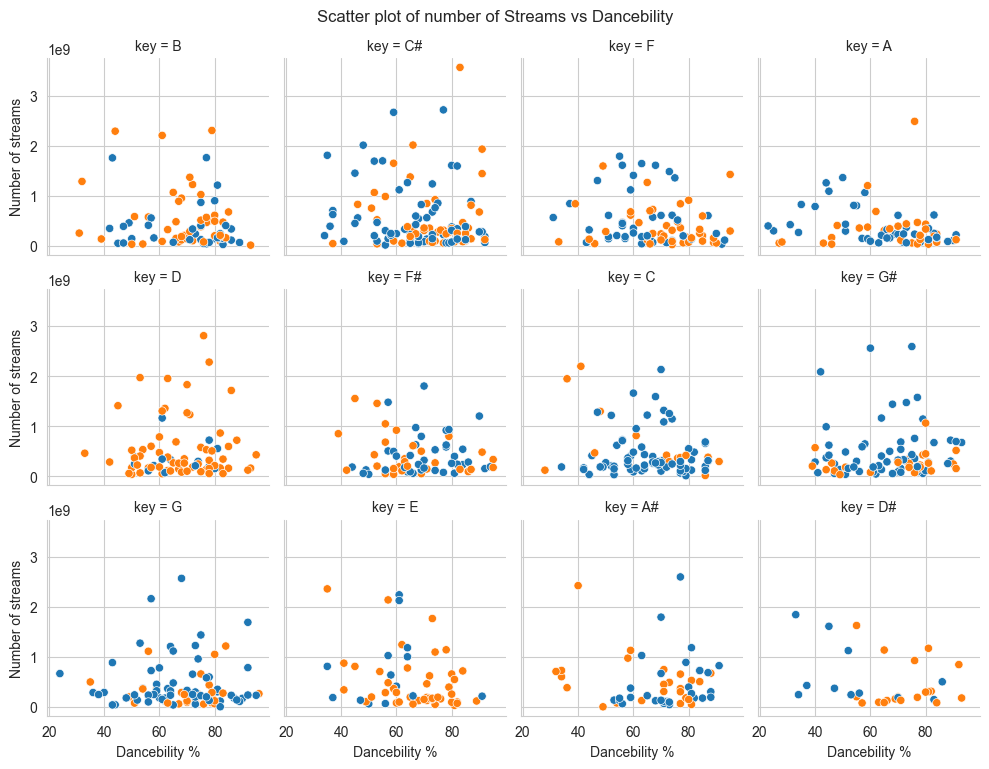

In [13]:
g = sns.FacetGrid(songs_data, col='key', col_wrap=4, height=2.5)
g.map_dataframe(sns.scatterplot, x='danceability_%', y='streams', hue='mode')
g.figure.suptitle('Scatter plot of number of Streams vs Dancebility', y=1.02)
g.set_axis_labels('Dancebility %', 'Number of streams')
plt.show()

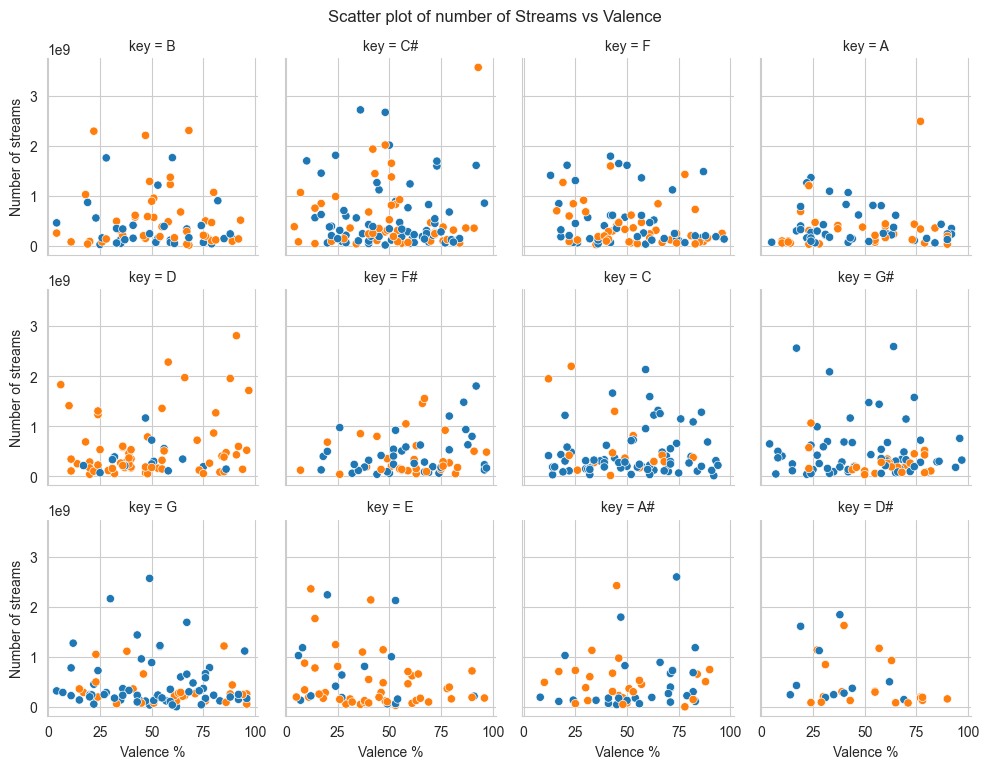

In [14]:
g = sns.FacetGrid(songs_data, col='key', col_wrap=4, height=2.5)
g.map_dataframe(sns.scatterplot, x='valence_%', y='streams', hue='mode')
g.figure.suptitle('Scatter plot of number of Streams vs Valence', y=1.02)
g.set_axis_labels('Valence %', 'Number of streams')
plt.show()

## Scatter Plots: Streams vs. Playlist Presence

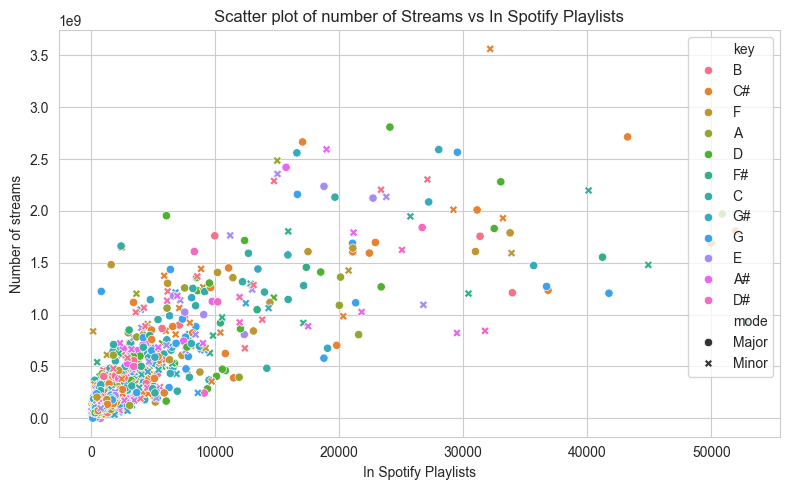

In [15]:
scatter_vs_streams('in_spotify_playlists', 'In Spotify Playlists', 'Scatter plot of number of Streams vs In Spotify Playlists')

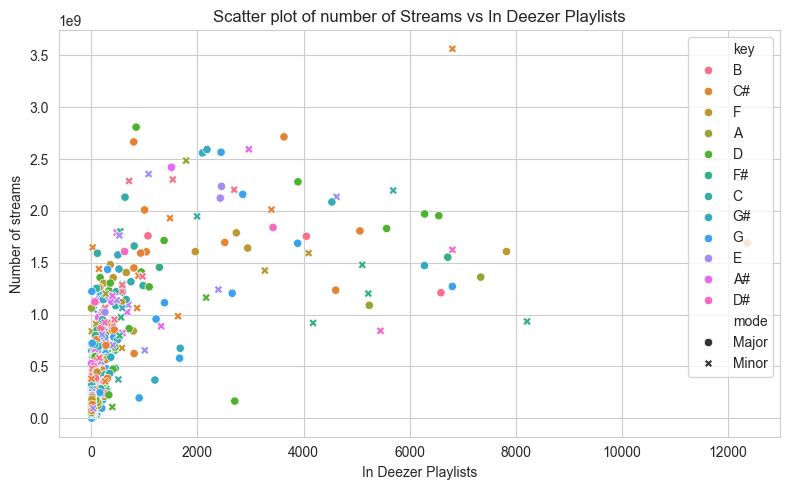

In [16]:
scatter_vs_streams('in_deezer_playlists', 'In Deezer Playlists', 'Scatter plot of number of Streams vs In Deezer Playlists')